# 04 · Calibration and abstention

A bounded-latency diarizer is less accurate than an offline one. If it also knows *which* of its turn decisions are probably wrong, a deployment can route that minority to a slower offline pass and buy most of the gap back. This notebook measures whether it does.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
os.environ.setdefault("OMP_NUM_THREADS", "2")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch; torch.set_num_threads(2)

TABLES = os.path.join("..", "results", "tables")
def table(name):
    return pd.read_csv(os.path.join(TABLES, name))
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)


In [2]:
cal = table('calibration.csv')
cols = ['method', 'seed', 'temperature', 'raw_accuracy', 'raw_mean_confidence',
        'raw_overconfidence', 'raw_ece', 'cal_ece', 'raw_ace', 'raw_brier',
        'raw_error_detection_auroc', 'raw_aurc', 'raw_aurc_oracle']
print(cal[[c for c in cols if c in cal.columns]].round(4).to_string(index=False))

      method  seed  temperature  raw_accuracy  raw_mean_confidence  raw_overconfidence  raw_ece  cal_ece  raw_ace  raw_brier  raw_error_detection_auroc  raw_aurc  raw_aurc_oracle
      online     0       0.0784        0.7809               0.6185             -0.1624   0.1695   0.0325   0.1624     0.1897                     0.6418    0.1760           0.0260
naive_online     0       0.0709        0.8204               0.6323             -0.1882   0.1956   0.0649   0.1905     0.1648                     0.7383    0.1019           0.0172
 offline_ahc     0       0.3172        0.7318               0.8372              0.1054   0.1058   0.1311   0.1054     0.1882                     0.6624    0.2294           0.0397
      online     1       0.1577        0.8253               0.6389             -0.1864   0.1921   0.1451   0.1864     0.1650                     0.7272    0.0971           0.0162
naive_online     1       0.1357        0.8182               0.6422             -0.1760   0.1797   0.1426 

`temperature` is fitted on the **dev** split only, never on test. `cal_ece` is the ECE after that single scalar recalibration.

Note the asymmetry that has to be stated: for the online system the confidence is the assignment margin *available at decision time*. For the offline system there was no decision time, so its confidence is a **post hoc** similarity to the final cluster centroid. The two are not the same kind of quantity.

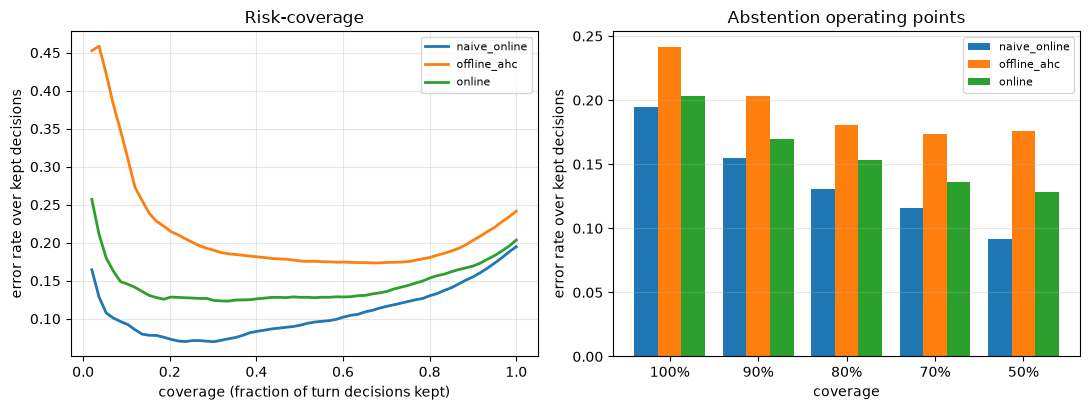

In [3]:
rc = table('risk_coverage.csv')
plt.figure(figsize=(11, 4.2))
plt.subplot(1, 2, 1)
for method, sub in rc.groupby('method'):
    grid = np.linspace(0.02, 1.0, 60)
    curves = [np.interp(grid, s.sort_values('coverage').coverage,
                        s.sort_values('coverage').risk)
              for _, s in sub.groupby('seed')]
    plt.plot(grid, np.mean(curves, axis=0), lw=2, label=method)
plt.xlabel('coverage (fraction of turn decisions kept)')
plt.ylabel('error rate over kept decisions')
plt.title('Risk-coverage'); plt.grid(alpha=0.3); plt.legend(fontsize=8)
plt.subplot(1, 2, 2)
cols = [c for c in cal.columns if c.startswith('risk_at_coverage_')]
cols = sorted(cols, key=lambda c: -int(c.rsplit('_', 1)[1]))
w = 0.8 / cal.method.nunique()
for i, (method, sub) in enumerate(cal.groupby('method')):
    plt.bar(np.arange(len(cols)) + i * w,
            [float(np.nanmean(sub[c])) for c in cols], w, label=method)
plt.xticks(np.arange(len(cols)) + 0.4 - w / 2,
           [c.rsplit('_', 1)[1] + '%' for c in cols])
plt.xlabel('coverage'); plt.ylabel('error rate over kept decisions')
plt.title('Abstention operating points'); plt.grid(alpha=0.3, axis='y')
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Reading the AUROC honestly

`raw_error_detection_auroc` is the probability that a randomly chosen *correct* decision is more confident than a randomly chosen *wrong* one. 0.5 is useless. Compare `raw_aurc` against `raw_aurc_oracle`: the oracle abstains on exactly the errors and is the achievable floor, not a target.

In [4]:
summ = table('calibration_summary.csv')
keep = ['method', 'raw_accuracy', 'raw_ece', 'raw_ece_noise_scale',
        'cal_ece', 'raw_error_detection_auroc',
        'raw_error_detection_auroc_noise_scale', 'raw_aurc', 'raw_aurc_oracle']
print(summ[[c for c in keep if c in summ.columns]].round(4).to_string(index=False))

      method  raw_accuracy  raw_ece  raw_ece_noise_scale  cal_ece  raw_error_detection_auroc  raw_error_detection_auroc_noise_scale  raw_aurc  raw_aurc_oracle
      online        0.7964   0.1779               0.0175   0.0835                     0.6754                                 0.0644    0.1485           0.0226
naive_online        0.8052   0.1718               0.0405   0.0943                     0.7392                                 0.0712    0.1105           0.0206
 offline_ahc        0.7584   0.0980               0.0237   0.1432                     0.6348                                 0.0726    0.2179           0.0325
